# Econ 390 - Lecture 14: More Plots
Today we will be going over making plots with Matplotlib that aren't line plots. Appropriate material is [the rest of Chapter 9 that is not about line plots in McKinney](https://wesmckinney.com/book/plotting-and-visualization) and similar for [Turrell](https://aeturrell.github.io/coding-for-economists/vis-matplotlib.html).

## Subplots

In [1]:
# As always
url = "https://m-mcmain.github.io/files/Econ390SP26/"
import pandas as pd, matplotlib.pyplot as plt
from datetime import datetime

USD_ER = pd.read_csv(url+"USD_ERs.csv", index_col = 0, parse_dates = True)
USD_ER = USD_ER.rename(columns={"DTWEXBGS_NBD20060101":"Broad USD", "DEXCHUS_NBD20060101":"CHY_USD","DEXUSEU_NBD20060101":"USD_EU"}) 
USD_ER

,Broad USD,CHY_USD,USD_EU
observation_date,,,
2006-01-01,100.00000,100.00000,100.00000
2006-02-01,100.21117,99.82489,98.46800
2006-03-01,100.42808,99.62384,99.19950
2006-04-01,99.74348,99.36736,101.21851
2006-05-01,97.51177,99.35193,105.29425
...,...,...,...
2025-07-01,120.52656,88.94931,96.25020
2025-08-01,120.98444,88.93206,96.05770
2025-09-01,120.45339,88.32157,96.81015


In [2]:
# Initialize our figure
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

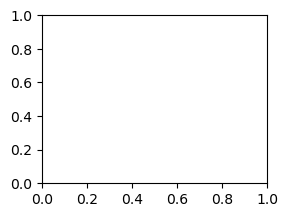

In [3]:
# Add Subplot method
ax1 = fig.add_subplot(2,2,1)
fig

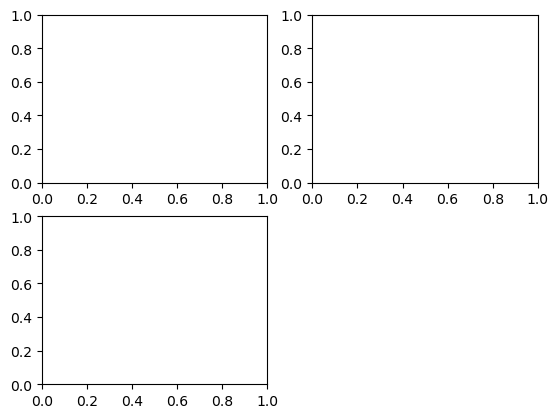

In [4]:
# More?
ax2 = fig.add_subplot(2,2,2)
ax3 = fig.add_subplot(2,2,3)
fig

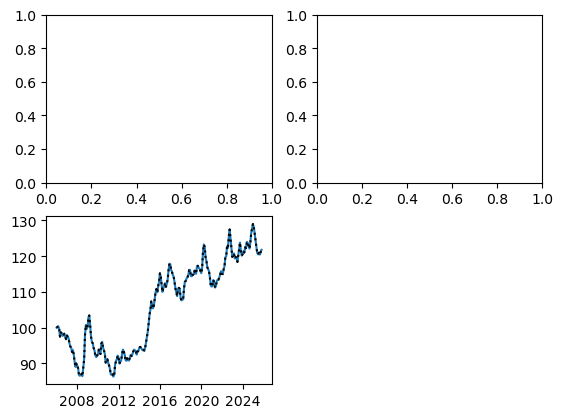

In [6]:
# Fill out one of the subplots
ax3.plot(USD_ER.index, USD_ER["Broad USD"], color = "black", linestyle=":")
fig

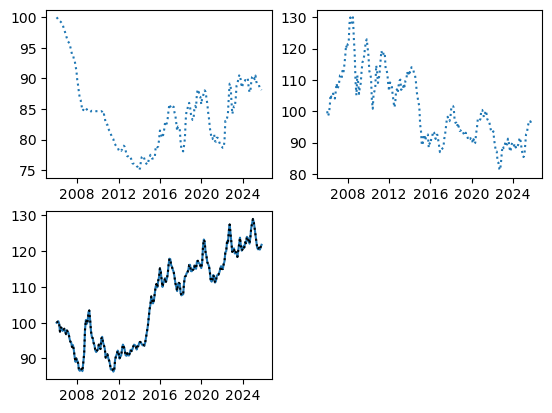

In [7]:
# And the others
ax1.plot(USD_ER.index, USD_ER['CHY_USD'], linestyle=":")
ax2.plot(USD_ER.index, USD_ER['USD_EU'], linestyle=":")
fig

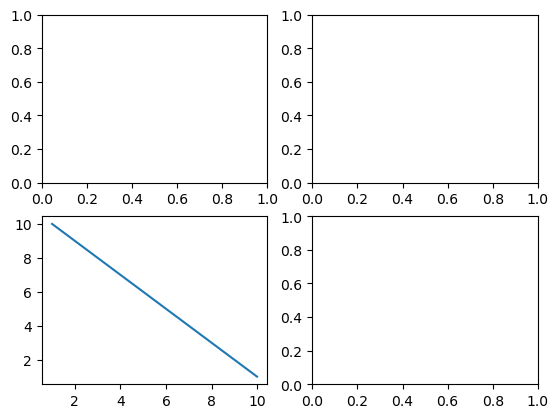

In [10]:
# Reshape to move panels around and access like a list
fig, ax = plt.subplots(2,2)
ax = ax.reshape(-1)
ax[2].plot([1, 10], [10,1])

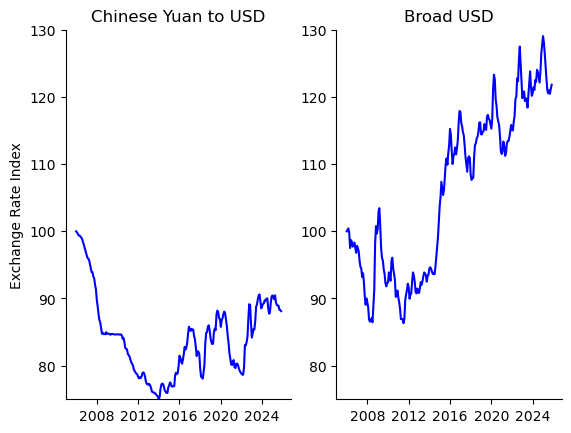

In [21]:
# Side by side subplots
plot_color = "blue"

fig, ax = plt.subplots(1,2)

ax[0].plot(USD_ER.index, USD_ER["CHY_USD"], color=plot_color)
ax[0].set(ylim=(75,130),
          title=("Chinese Yuan to USD"),
          ylabel=("Exchange Rate Index"))
ax[0].spines[["top","right"]].set_visible(False)

ax[1].plot(USD_ER.index, USD_ER["Broad USD"], color=plot_color)
ax[1].set(ylim=(75,130),
          title=("Broad USD"))
ax[1].spines[["top","right"]].set_visible(False)

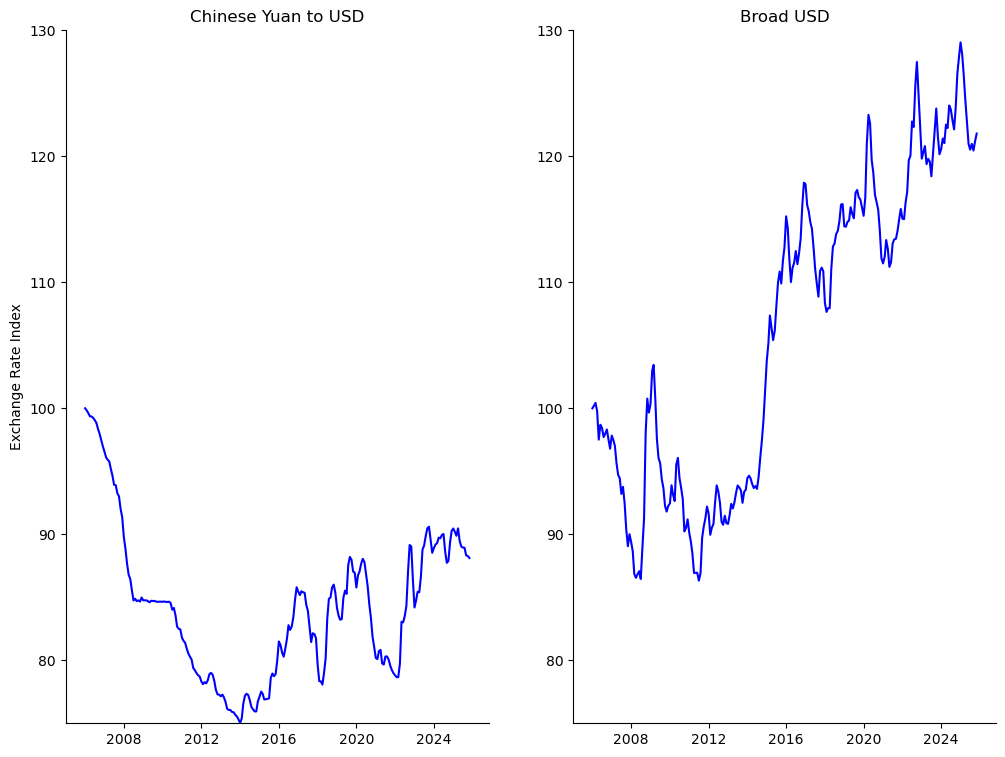

In [24]:
# Making it look a bit nicer
plot_color = "blue"

fig, ax = plt.subplots(1,2,figsize=(12,9))

ax[0].plot(USD_ER.index, USD_ER["CHY_USD"], color=plot_color)
ax[0].set(ylim=(75,130),
          title=("Chinese Yuan to USD"),
          ylabel=("Exchange Rate Index"))
ax[0].spines[["top","right"]].set_visible(False)

ax[1].plot(USD_ER.index, USD_ER["Broad USD"], color=plot_color)
ax[1].set(ylim=(75,130),
          title=("Broad USD"))
ax[1].spines[["top","right"]].set_visible(False)

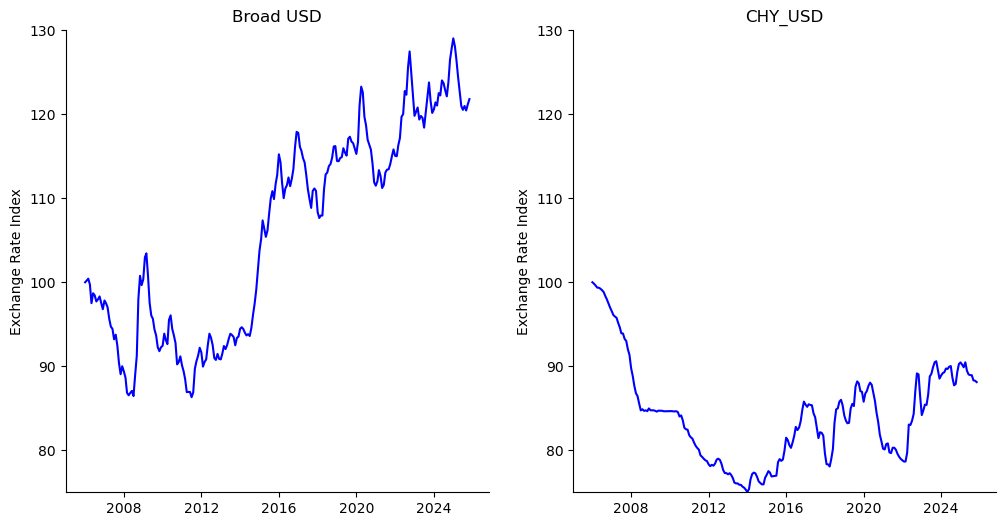

In [29]:
# Let's utilize a loop to be more efficient
fig, ax = plt.subplots(1,2, figsize=(12,6))
# To do so, we need a subset that only has CHY_USD and USD_Broad
USD_ER_CHYBroad = USD_ER.drop("USD_EU", axis=1)

for i, ER in enumerate(USD_ER_CHYBroad.columns):
    ax[i].plot(USD_ER.index, USD_ER[ER], color=plot_color)
    ax[i].set(ylim=(75,130),
              title=(ER),
              ylabel=("Exchange Rate Index"))
    ax[i].spines[["top","right"]].set_visible(False)    

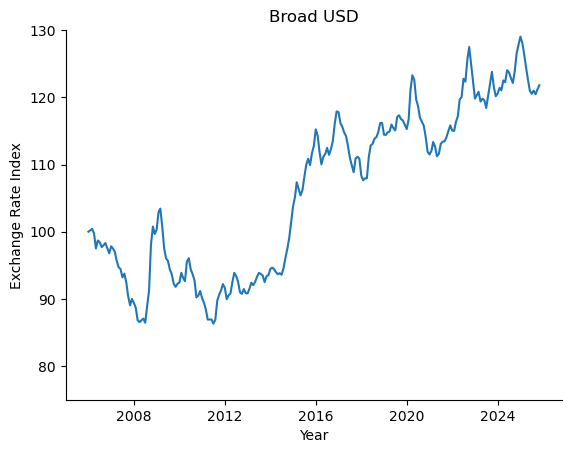

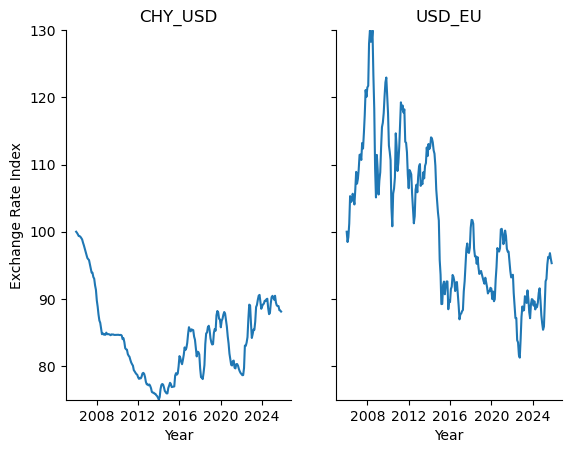

In [37]:
# Generate World Plot
fig, ax = plt.subplots()
ax.plot(USD_ER.index, USD_ER["Broad USD"])
ax.set(ylim=(75, 130), 
       title="Broad USD",
       xlabel="Year",
       ylabel="Exchange Rate Index")

ax.spines[["top","right"]].set_visible(False)

# Generate Regional Plots
fig, ax = plt.subplots(1, 2, sharex = True, sharey = True)
ax = ax.reshape(-1)

for i, ER in enumerate(USD_ER.columns[USD_ER.columns != "Broad USD"]):
    ax[i].plot(USD_ER.index, USD_ER[ER], label=ER)
    ax[i].set(title=ER, ylim=(75, 130))
    ax[i].spines[["top","right"]].set_visible(False)

# Label Regional Graph Axes
ax[0].set_ylabel("Exchange Rate Index")
ax[0].set_xlabel("Year")
ax[1].set_xlabel("Year")
plt.show()

## Histograms

In [38]:
# Calculating percent growth of variables
USD_ER["Broad USD Growth"] = USD_ER["Broad USD"].pct_change()*100
USD_ER

,Broad USD,CHY_USD,USD_EU,Broad USD Growth
observation_date,,,,
2006-01-01,100.00000,100.00000,100.00000,NaN
2006-02-01,100.21117,99.82489,98.46800,0.211170
2006-03-01,100.42808,99.62384,99.19950,0.216453
2006-04-01,99.74348,99.36736,101.21851,-0.681682
2006-05-01,97.51177,99.35193,105.29425,-2.237450
...,...,...,...,...
2025-07-01,120.52656,88.94931,96.25020,-0.370449
2025-08-01,120.98444,88.93206,96.05770,0.379900
2025-09-01,120.45339,88.32157,96.81015,-0.438941


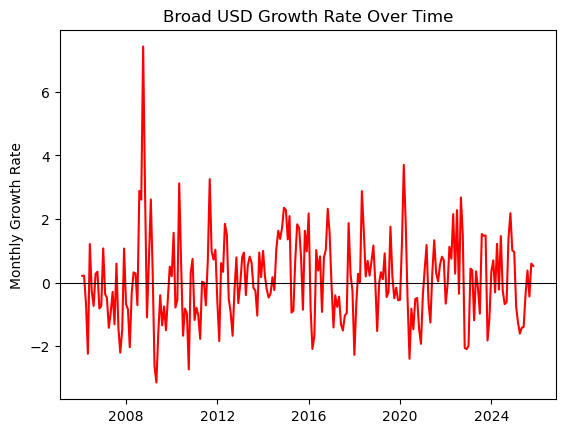

In [41]:
# Plotting growth rates
fig, ax = plt.subplots()

ax.plot(USD_ER.index, USD_ER["Broad USD Growth"], color="red")
ax.set(ylabel="Monthly Growth Rate", title="Broad USD Growth Rate Over Time");
# Add a horizontal line at y=0 for reference
ax.axhline(y=0, color="black", linewidth=0.75);

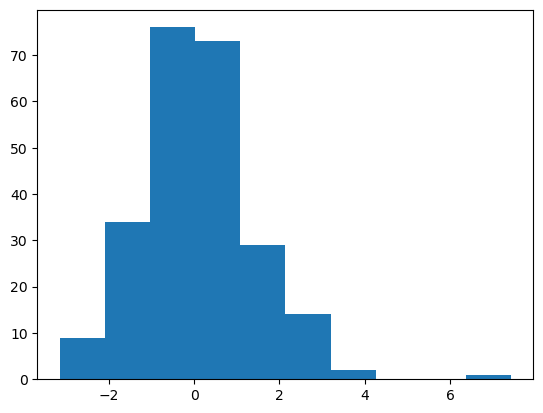

In [42]:
# Histogram is more suitable
fig, ax = plt.subplots()

ax.hist(USD_ER["Broad USD Growth"])

plt.show()

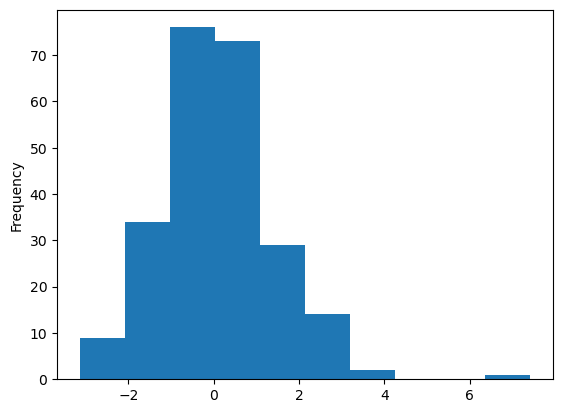

In [43]:
# Default methods
ax = USD_ER["Broad USD Growth"].plot.hist()

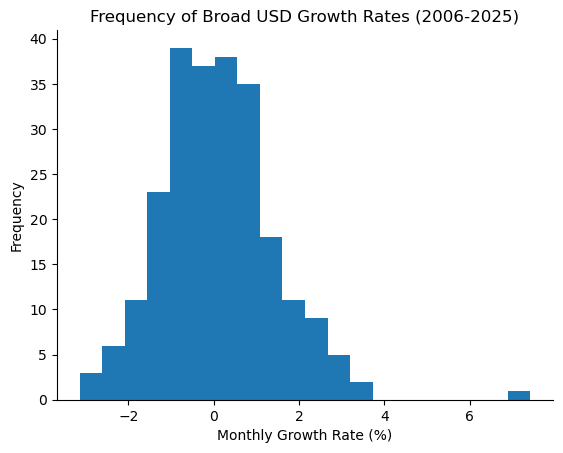

In [46]:
# Adding our usuals
fig, ax = plt.subplots()

ax.hist(USD_ER["Broad USD Growth"], bins=20)
ax.set(ylabel="Frequency",
       xlabel="Monthly Growth Rate (%)",
       title="Frequency of Broad USD Growth Rates (2006-2025)")

ax.spines[["right","top",]].set_visible(False)

plt.show()

## Practice - Histograms
Try the following changes:
1. Make a plot with two subplots (side-by-side), where the first shows the data from 2006-2012 and the second shows the data 2013–2024
3. Change the figsize, bin, alpha, and color arguments to whatever you like!
4. Add a vertical line at zero. *Hint: Knowing how to do a horizontal line, how would you make it vertical?*
5. Challenging: For each of the two plots, compute the mean annual percent growth rate for that time period and put the vertical line there instead of at zero

In [ ]:
# Reference Code
fig, ax1 = plt.subplots(figsize=(16,9))
ax1.hist(USD_ER['Broad USD Growth'], bins=20, alpha=1, color='navy')
ax1.set(ylabel='Frequency',
        xlabel='Monthly growth rate (%)',
        title='Frequency of Broad USD growth rates (2006-2025)')
ax1.spines[['right','top']].set_visible(False)
plt.show()

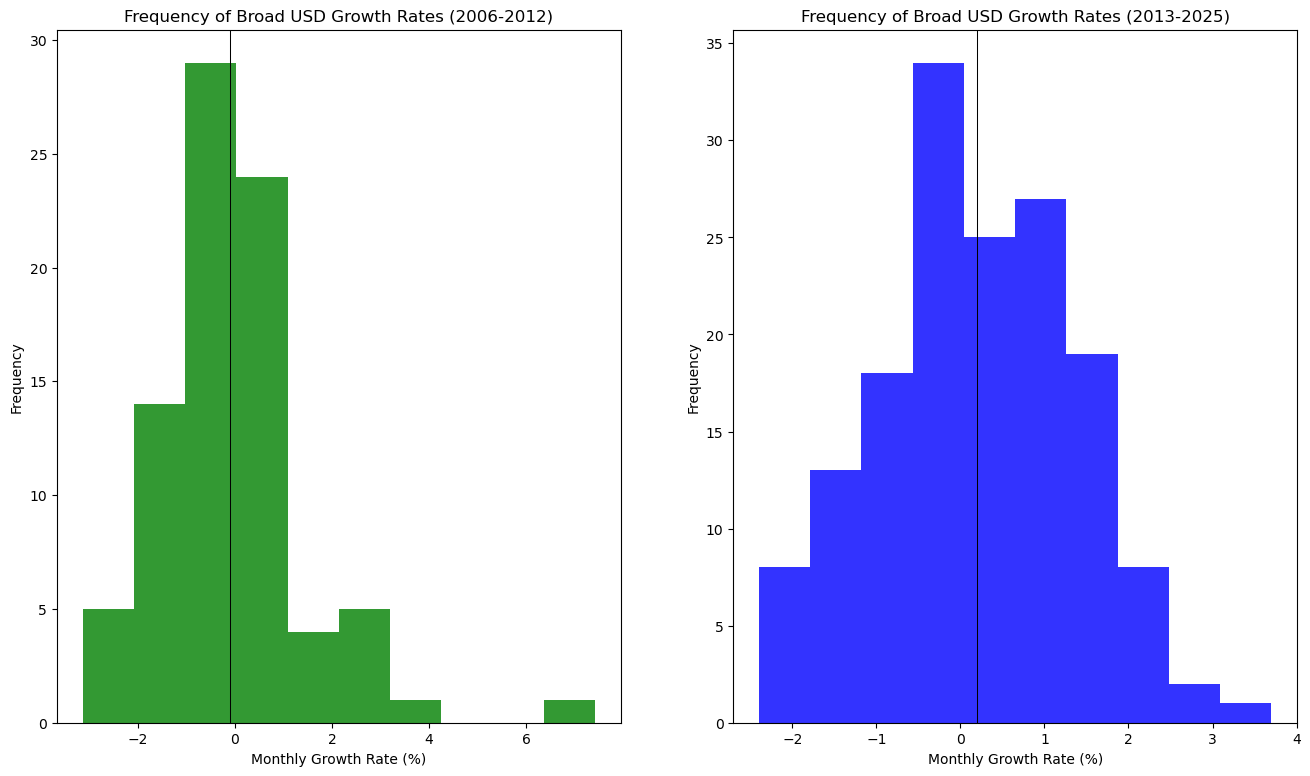

In [56]:
# Practice
avg_USD_growth_early = USD_ER["Broad USD Growth"].loc[USD_ER.index <= datetime(2012,12,1)].mean()
avg_USD_growth_late = USD_ER["Broad USD Growth"].loc[USD_ER.index > datetime(2012,12,1)].mean()

fig, ax = plt.subplots(1,2, figsize=(16,9))

ax[0].hist(USD_ER['Broad USD Growth'].loc[USD_ER.index <= datetime(2012,12,1)], alpha = 0.8, color="green")
ax[0].set(ylabel="Frequency",
          xlabel="Monthly Growth Rate (%)",
          title="Frequency of Broad USD Growth Rates (2006-2012)")
ax[0].axvline(x=avg_USD_growth_early, color="black", linewidth=0.75);

ax[1].hist(USD_ER['Broad USD Growth'].loc[USD_ER.index > datetime(2012,12,1)], alpha = 0.8, color="blue")
ax[1].set(ylabel="Frequency",
          xlabel="Monthly Growth Rate (%)",
          title="Frequency of Broad USD Growth Rates (2013-2025)")
ax[1].axvline(x=avg_USD_growth_late, color="black", linewidth=0.75);

plt.show()

## Bar Plots

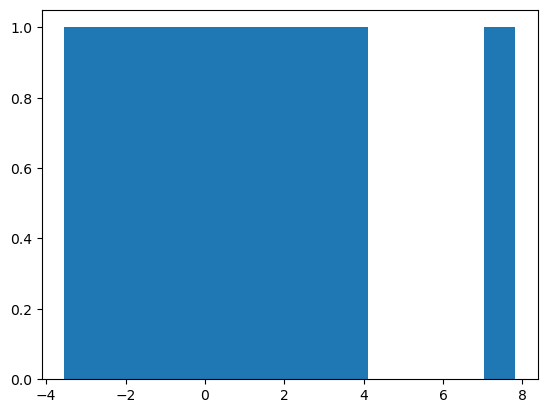

In [59]:
# Tally the number of times each percent growth rate occurs
Broad_USD_counts = pd.crosstab(USD_ER["Broad USD Growth"], "Frequency")

# Generate a bar chart
fig, ax = plt.subplots()
ax.bar(x = Broad_USD_counts.index, height=Broad_USD_counts["Frequency"])
plt.show()

In [60]:
# Go back to our manufacturing data
ENIA_emp = pd.read_stata(url + "FUSION_annual_1995_EMP.dta")
ENIA_emp

,NUI,REGION,CIIU3,TOTHOM,TOTMUJ,REMEMP,REGEMP,REMCOM,REGCOM,REMOBR,REGOBR,TOHSC,TOMSC,EXPORTADOS
0,10082.0,2,3610,14,1,7466,0,0,0,20174,600,0,0,0.0
1,10101.0,2,2720,427,25,2046170,184590,0,0,810717,216003,0,0,1.0
2,10103.0,2,1531,46,6,135873,3426,69814,2912,37037,3848,0,0,0.0
3,10178.0,4,1512,39,35,22958,1886,0,0,40257,4394,0,0,0.0
4,10220.0,5,3312,481,15,554636,187853,0,0,858571,290794,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,23429.0,13,2520,39,0,7990,790,0,0,25334,3874,2,0,0.0
96,23437.0,13,2520,81,6,88656,1432,3284,0,117469,9895,9,0,1.0
97,23449.0,6,2924,145,0,914130,54126,0,0,267928,31246,0,0,0.0
98,40088.0,8,3693,3,3,13495,271,0,0,0,0,0,0,0.0


In [61]:
# Convert Data
ENIA_emp["EXPORTADOS"] = ENIA_emp["EXPORTADOS"].astype(str)
ENIA_emp.loc[ENIA_emp["EXPORTADOS"]=="0.0","EXPORTADOS"] = "No Exports"
ENIA_emp.loc[ENIA_emp["EXPORTADOS"]=="1.0","EXPORTADOS"] = "Exported"
ENIA_emp

,NUI,REGION,CIIU3,TOTHOM,TOTMUJ,REMEMP,REGEMP,REMCOM,REGCOM,REMOBR,REGOBR,TOHSC,TOMSC,EXPORTADOS
0,10082.0,2,3610,14,1,7466,0,0,0,20174,600,0,0,No Exports
1,10101.0,2,2720,427,25,2046170,184590,0,0,810717,216003,0,0,Exported
2,10103.0,2,1531,46,6,135873,3426,69814,2912,37037,3848,0,0,No Exports
3,10178.0,4,1512,39,35,22958,1886,0,0,40257,4394,0,0,No Exports
4,10220.0,5,3312,481,15,554636,187853,0,0,858571,290794,0,0,Exported
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,23429.0,13,2520,39,0,7990,790,0,0,25334,3874,2,0,No Exports
96,23437.0,13,2520,81,6,88656,1432,3284,0,117469,9895,9,0,Exported
97,23449.0,6,2924,145,0,914130,54126,0,0,267928,31246,0,0,No Exports
98,40088.0,8,3693,3,3,13495,271,0,0,0,0,0,0,No Exports


In [62]:
# Gen total employment
ENIA_emp["TOTEMP"] = ENIA_emp["TOTHOM"]+ENIA_emp["TOTMUJ"]+ENIA_emp["TOHSC"]+ENIA_emp["TOMSC"]
ENIA_emp

,NUI,REGION,CIIU3,TOTHOM,TOTMUJ,REMEMP,REGEMP,REMCOM,REGCOM,REMOBR,REGOBR,TOHSC,TOMSC,EXPORTADOS,TOTEMP
0,10082.0,2,3610,14,1,7466,0,0,0,20174,600,0,0,No Exports,15
1,10101.0,2,2720,427,25,2046170,184590,0,0,810717,216003,0,0,Exported,452
2,10103.0,2,1531,46,6,135873,3426,69814,2912,37037,3848,0,0,No Exports,52
3,10178.0,4,1512,39,35,22958,1886,0,0,40257,4394,0,0,No Exports,74
4,10220.0,5,3312,481,15,554636,187853,0,0,858571,290794,0,0,Exported,496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,23429.0,13,2520,39,0,7990,790,0,0,25334,3874,2,0,No Exports,41
96,23437.0,13,2520,81,6,88656,1432,3284,0,117469,9895,9,0,Exported,96
97,23449.0,6,2924,145,0,914130,54126,0,0,267928,31246,0,0,No Exports,145
98,40088.0,8,3693,3,3,13495,271,0,0,0,0,0,0,No Exports,6


In [64]:
# Calculate number of times each outcome occurs
exported_counts = pd.crosstab(ENIA_emp["EXPORTADOS"], "Frequency")
exported_counts

col_0,Frequency
EXPORTADOS,
Exported,23
No Exports,77


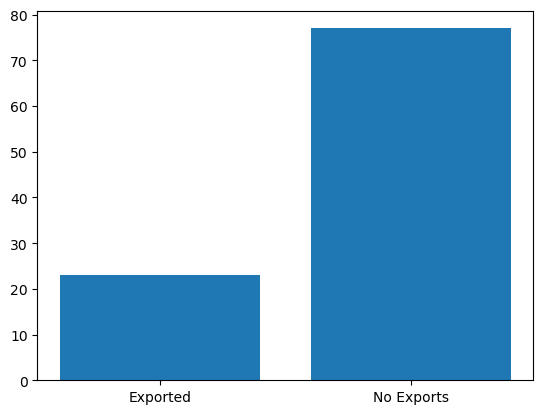

In [66]:
# Generate bar chart
fig, ax = plt.subplots()
ax.bar(exported_counts.index, exported_counts["Frequency"])
plt.show()

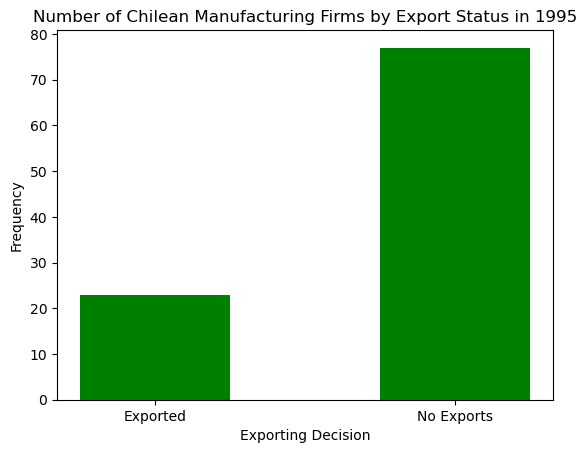

In [68]:
# We can use similar options as before
fig, ax = plt.subplots()
ax.bar(exported_counts.index, exported_counts["Frequency"], color="green", width=0.5)
ax.set(ylabel="Frequency",
       xlabel="Exporting Decision",
       title="Number of Chilean Manufacturing Firms by Export Status in 1995")
plt.show()

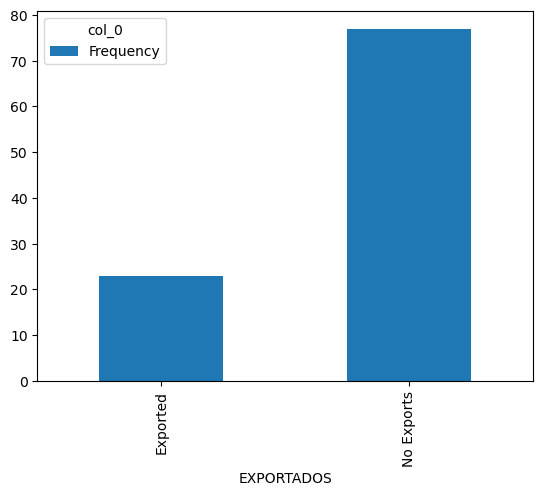

In [69]:
# Some changes
ax = exported_counts.plot.bar()

## Practice - Bar Plots
Try the following changes to the bar chart above:
1. Try displaying percentages instead of counts. *Hint: You only need to change the crosstab statement. Look back to Lecture 12 if you've forgotten.*
2. Can we make this a horizontal bar chart? It’s pretty easy actually. Instead of the bar method, try the barh method. Do we get an error? Why?

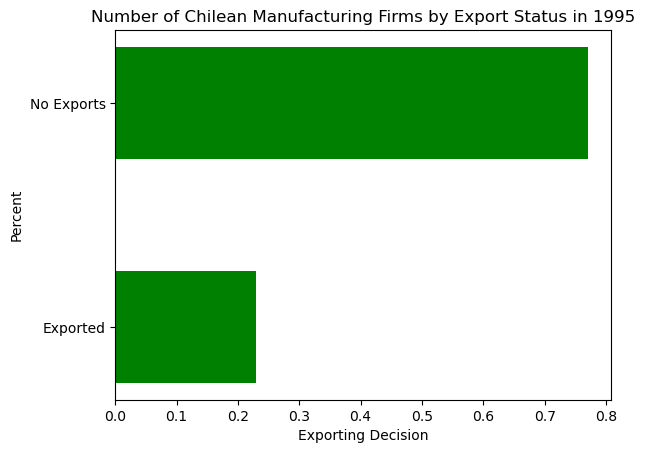

In [73]:
# We can use similar options as before
exported_counts = pd.crosstab(ENIA_emp["EXPORTADOS"], "Percent", normalize="columns")

fig, ax = plt.subplots()
ax.barh(exported_counts.index, exported_counts["Percent"], color="green", height=0.5)
ax.set(ylabel="Percent",
       xlabel="Exporting Decision",
       title="Number of Chilean Manufacturing Firms by Export Status in 1995")
plt.show()